In [1]:
import os
# must come *before* any Tensorflow import
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['CUDA_LAUNCH_BLOCKING'] = '0'

In [2]:
import pandas as pd
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import tensorflow as tf
import matplotlib.image as mpimg
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from sklearn.metrics import classification_report
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.layers import Dense, Flatten, Conv2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Recall
from tensorflow.keras.models import Sequential
import segmentation_models as sm

Segmentation Models: using `keras` framework.


In [3]:
def set_seed(seed_value=12345):
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)

set_seed()
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
def load_split(base_dir, split):
    images_dir = os.path.join(base_dir, split, 'images')
    masks_dir  = os.path.join(base_dir, split, 'masks')
    
    X, y, labels = [], [], []
    
    # Iterate over numbered subfolders (1, 2, 3, ...)
    for subfolder in sorted(os.listdir(images_dir)):
        sub_img_dir  = os.path.join(images_dir, subfolder)
        sub_mask_dir = os.path.join(masks_dir,  subfolder)
        
        if not os.path.isdir(sub_img_dir):  # skip non-folders
            continue

        if subfolder == 'no_tumor':  # skip no_tumor subfolder for segmentation
            continue
        
        for fname in sorted(os.listdir(sub_img_dir)):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
                continue
            
            # Parse label: <global_id>_<patient_id>_<label>.ext
            label = fname.rsplit('.', 1)[0].split('_')[-1]
            
            img  = Image.open(os.path.join(sub_img_dir,  fname)).convert('RGB')
            mask = Image.open(os.path.join(sub_mask_dir, fname)).convert('L')
            
            img  = img.resize((224, 224))
            mask = mask.resize((224, 224))
            
            X.append(np.array(img))
            y.append(np.array(mask))
            labels.append(label)
    
    return np.array(X), np.array(y), labels

File name :  113_108590_1.jpg
Image shape: (512, 512)


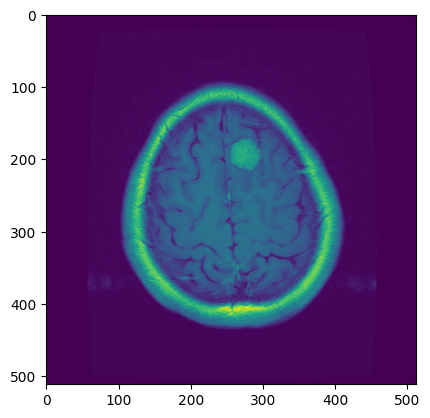

File name :  113_108590_1.jpg
Image shape: (512, 512)


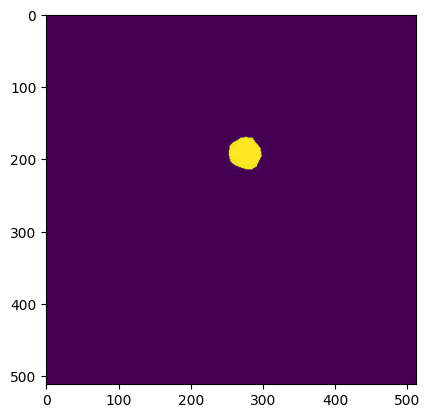

TRAIN FILES
['101_107494_1.jpg', '102_107494_1.jpg', '103_107494_1.jpg', '111_108550_1.jpg', '112_108550_1.jpg', '113_108590_1.jpg', '114_108590_1.jpg', '115_108945_1.jpg', '116_108945_1.jpg']
MASK FILES
['101_107494_1.jpg', '102_107494_1.jpg', '103_107494_1.jpg', '111_108550_1.jpg', '112_108550_1.jpg', '113_108590_1.jpg', '114_108590_1.jpg', '115_108945_1.jpg', '116_108945_1.jpg']


In [5]:
BASE_DIR = '../data/figshare_braintumor_split'
TRAIN_PATH = os.path.join(BASE_DIR, 'train', 'images', '1')
MASK_PATH = os.path.join(BASE_DIR, 'train', 'masks', '1')

train_images_files = os.listdir(TRAIN_PATH)
train_masks_files = os.listdir(MASK_PATH)
image_filename = train_images_files[6]
mask_filename = train_masks_files[6]
image_path = os.path.join(TRAIN_PATH, image_filename)
mask_path = os.path.join(MASK_PATH, mask_filename)

im = mpimg.imread(image_path)
im_mask = mpimg.imread(mask_path)
print("File name : ",image_filename)
print(f"Image shape: {im.shape}")
plt.imshow(im)
plt.show()
print("File name : ",mask_filename)
print(f"Image shape: {im_mask.shape}")
plt.imshow(im_mask)
plt.show()
print("TRAIN FILES")
print(train_images_files[1:10])
print("MASK FILES")
print(train_masks_files[1:10])

In [6]:
X_train, y_train, train_labels = load_split(BASE_DIR, 'train')
X_val, y_val, val_labels = load_split(BASE_DIR, 'val')
X_test, y_test, test_labels = load_split(BASE_DIR, 'test')

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2212, 224, 224, 3)
y_train shape: (2212, 224, 224)
X_val shape: (222, 224, 224, 3)
y_val shape: (222, 224, 224)
X_test shape: (630, 224, 224, 3)
y_test shape: (630, 224, 224)


In [7]:
from collections import Counter

print("Class distribution in TRAIN:")
print(Counter(train_labels)) 

print("\nClass distribution in VAL:")
print(Counter(val_labels))

print("\nClass distribution in VAL:")
print(Counter(test_labels))

Class distribution in TRAIN:
Counter({'2': 1019, '3': 683, '1': 510})

Class distribution in VAL:
Counter({'2': 115, '3': 73, '1': 34})

Class distribution in VAL:
Counter({'2': 292, '3': 174, '1': 164})


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train_labels)
y_train_enc = le.transform(train_labels)
y_val_enc = le.transform(val_labels)
y_test_enc = le.transform(test_labels)

print("Classes:", le.classes_)

Classes: ['1' '2' '3']


<h1>SEGMENTATION<h1>

In [9]:
import numpy as np

# Binarize masks + add channel dimension
y_train_mask = np.expand_dims((y_train > 127).astype(np.float32), axis=-1)
y_val_mask   = np.expand_dims((y_val > 127).astype(np.float32), axis=-1)
y_test_mask  = np.expand_dims((y_test > 127).astype(np.float32), axis=-1)

print("New mask shapes:")
print("Train:", y_train_mask.shape)
print("Val:", y_val_mask.shape)
print("Test:", y_test_mask.shape)

New mask shapes:
Train: (2212, 224, 224, 1)
Val: (222, 224, 224, 1)
Test: (630, 224, 224, 1)


In [10]:
from keras_unet_collection import models
import tensorflow as tf

input_shape = (224, 224, 3)

# U-net
unet = models.unet_2d(
    input_shape,
    filter_num=[64, 128, 256, 512],
    n_labels=1,
    stack_num_down=2,
    stack_num_up=2,
    activation='ReLU',
    output_activation='Sigmoid',
    batch_norm=True,
    pool='max',
    unpool=False,
    backbone='VGG16',
    weights='imagenet',
    freeze_backbone=False,
    freeze_batch_norm=False,
    name='unet'
)

unet.summary()

c:\Users\Pruck\miniconda3\envs\dl_364\lib\site-packages\keras_unet_collection\_backbone_zoo.py:45: UserWarning: 

Backbone VGG16 does not use batch norm, but other layers received batch_norm=True
  warnings.warn(param_mismatch);


Model: "unet_model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 VGG16_backbone (Functional)    [(None, 224, 224, 6  7635264     ['input_1[0][0]']                
                                4),                                                               
                                 (None, 112, 112, 1                                               
                                28),                                                              
                                 (None, 56, 56, 256                                      

In [11]:
from tensorflow.keras import backend as K

def dice_coef(y_true, y_pred, smooth=1e-6):
    # Flatten spatial dims only, preserving batch dimension
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])  # (batch, H*W)
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])  # (batch, H*W)

    intersection = K.sum(y_true_f * y_pred_f, axis=1)         # per sample
    dice = (2. * intersection + smooth) / (K.sum(y_true_f, axis=1) + K.sum(y_pred_f, axis=1) + smooth)
    return K.mean(dice)  # mean Dice across batch

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

In [12]:
dice_loss = sm.losses.DiceLoss()

In [13]:
import keras
iou_metric = keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name='iou')

In [14]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up Image generator
datagen = ImageDataGenerator(
    rotation_range=20,      # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.2,   # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=True, # randomly flip images
    vertical_flip=False,   # randomly flip images
)

#image_generator_X = datagen.flow(X_train, seed=12345)
#image_generator_y = datagen.flow(y_train_mask, seed=12345)

#train_generator = zip(image_generator_X, image_generator_y)

In [15]:
unet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[iou_metric, 'accuracy']
)

unet_history = unet.fit(X_train, y_train_mask, validation_data=(X_val, y_val_mask), batch_size=8,epochs=20)

Epoch 1/20
277/277 [==============================] - 78s 267ms/step - loss: 0.8158 - iou: 0.1083 - accuracy: 0.8895 - val_loss: 0.8425 - val_iou: 0.1701 - val_accuracy: 0.9402
Epoch 2/20
277/277 [==============================] - 69s 249ms/step - loss: 0.6089 - iou: 0.4643 - accuracy: 0.9854 - val_loss: 0.6735 - val_iou: 0.4100 - val_accuracy: 0.9867
Epoch 3/20
277/277 [==============================] - 74s 266ms/step - loss: 0.4471 - iou: 0.5610 - accuracy: 0.9901 - val_loss: 0.5302 - val_iou: 0.4372 - val_accuracy: 0.9893
Epoch 4/20
277/277 [==============================] - 86s 312ms/step - loss: 0.3494 - iou: 0.6023 - accuracy: 0.9918 - val_loss: 0.4393 - val_iou: 0.4541 - val_accuracy: 0.9893
Epoch 5/20
277/277 [==============================] - 87s 314ms/step - loss: 0.2833 - iou: 0.6417 - accuracy: 0.9930 - val_loss: 0.4417 - val_iou: 0.4369 - val_accuracy: 0.9900
Epoch 6/20
277/277 [==============================] - 71s 255ms/step - loss: 0.2479 - iou: 0.6580 - accuracy: 0.993

KeyboardInterrupt: 

<h2>TRY ON SOME TEST DATA<h2>

1/1 [==============================] - 1s 798ms/step


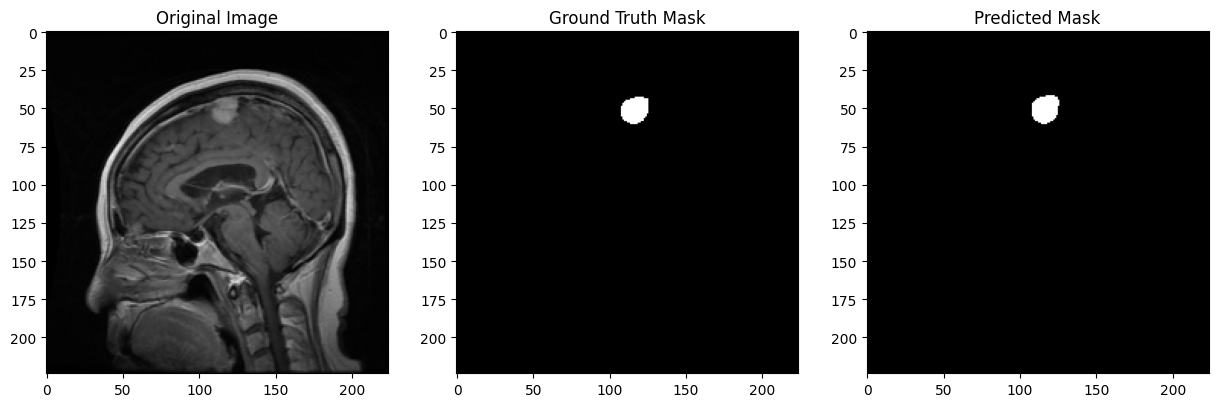

In [ ]:
import matplotlib.pyplot as plt

# Pick a random index from the test set
idx = 124
test_img = X_test[idx]
ground_truth = y_test_mask[idx]

# The model expects a batch, so we expand dims from (224,224,3) to (1,224,224,3)
pred_prob = unet.predict(np.expand_dims(test_img, axis=0))[0] 

# Apply threshold to binarize the prediction
pred_mask = (pred_prob > 0.5).astype(np.float32)

# Plotting
fig, arr = plt.subplots(1, 3, figsize=(15, 5))
arr[0].imshow(test_img)
arr[0].set_title('Original Image')

# .squeeze() removes the channel dimension (224,224,1) -> (224,224) for matplotlib
arr[1].imshow(ground_truth.squeeze(), cmap='gray') 
arr[1].set_title('Ground Truth Mask')

arr[2].imshow(pred_mask.squeeze(), cmap='gray')
arr[2].set_title('Predicted Mask')

plt.show()

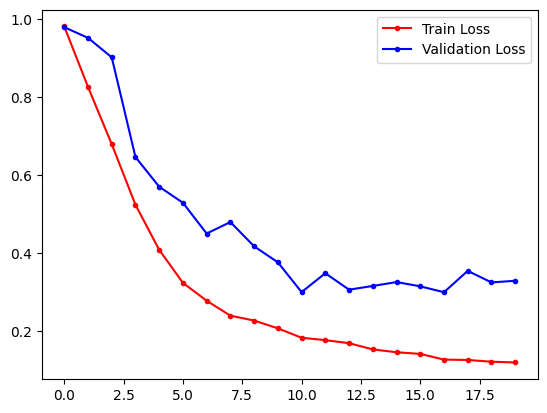

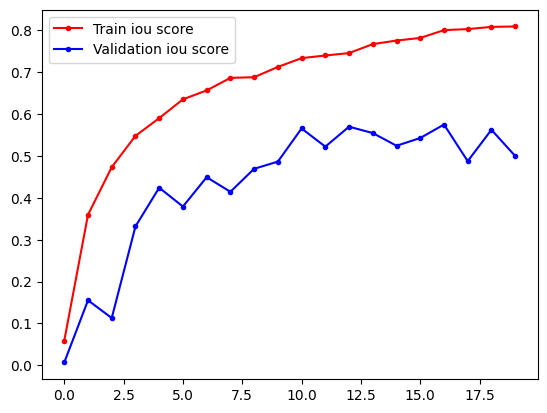

In [ ]:
fig, ax= plt.subplots()
ax.plot(unet_history.history["loss"], 'r', marker='.', label="Train Loss")
ax.plot(unet_history.history["val_loss"], 'b', marker='.', label="Validation Loss")
ax.legend()

fig, cx = plt.subplots()
cx.plot(unet_history.history["iou"], 'r', marker='.', label="Train iou score")
cx.plot(unet_history.history["val_iou"], 'b', marker='.', label="Validation iou score")
cx.legend()
plt.show()

In [ ]:
#unet.save('brain_tumor_unet_30.keras')